In [17]:
import os
import joblib
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

from utils import  evaluate_and_plot_predictions,asymmetric_profit_loss,set_seed,plot_training_history_with_lr,create_sequences
set_seed(42)

Сид установлен на 42 для Python, NumPy, TensorFlow и PYTHONHASHSEED.


#  Подготовка данных

In [18]:
df_features = pd.read_csv('data/features.csv')

target_col = 'consumption'
feature_cols = [col for col in df_features.columns if col not in ['timestamp', target_col]]

split_idx = int(len(df_features) * 0.8)
train_df = df_features.iloc[:split_idx].copy()
test_df = df_features.iloc[split_idx:].copy()

train_X_raw = train_df[feature_cols].values
test_X_raw = test_df[feature_cols].values

train_y_raw = train_df[target_col].values
test_y_raw = test_df[target_col].values

train_dates = pd.to_datetime(train_df['timestamp']).values
test_dates = pd.to_datetime(test_df['timestamp']).values

SEQ_LEN = 24  
HORIZON = 24   


X_train, y_train, dates_train = create_sequences(train_X_raw, train_y_raw, train_dates, SEQ_LEN, HORIZON)
X_test, y_test, dates_test = create_sequences(test_X_raw, test_y_raw, test_dates, SEQ_LEN, HORIZON)


# Cтандартизация признаков X

In [19]:
n_features = X_train.shape[2]
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_features)
X_test_2d  = X_test.reshape(-1, n_features)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(X_train_2d).reshape(X_train.shape)
X_test_scaled  = scaler.transform(X_test_2d).reshape(X_test.shape)

joblib.dump(scaler, 'model_weights/scaler_lstm.joblib')

['model_weights/scaler_lstm.joblib']

# Архитектура LSTM

In [20]:
model_lstm = models.Sequential([
    layers.Input(shape=(SEQ_LEN, n_features)),
    
    layers.LSTM(128, return_sequences=True, activation='tanh',
                kernel_regularizer=regularizers.l2(1e-5)), 
    layers.LayerNormalization(), 
 
    layers.LSTM(64, return_sequences=False, activation='tanh',
                kernel_regularizer=regularizers.l2(1e-5)),
    layers.LayerNormalization(), 
   
    layers.Dense(64, activation='swish'),
    layers.Dense(32, activation='swish'),
    
    layers.Dense(HORIZON, activation='linear')
])


In [21]:

model_lstm.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=5e-4, clipvalue=0.5), 
    loss=asymmetric_profit_loss, 
    metrics=['mae']
)

model_lstm.summary()

callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.75, patience=10, min_lr=1e-6, verbose=1),
    callbacks.TerminateOnNaN()
]

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 24, 128)        │        95,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ (None, 24, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_5           │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,056 (593.97 KB)

 Trainable params: 152,056 (593.97 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history_lstm = model_lstm.fit(
    X_train_scaled, y_train,
    epochs=300,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 370.4391 - mae: 10.0022 - val_loss: 86.7945 - val_mae: 4.7485 - learning_rate: 5.0000e-04
Epoch 2/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 15.4501 - mae: 1.5291 - val_loss: 0.1118 - val_mae: 0.2603 - learning_rate: 5.0000e-04
Epoch 3/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.1174 - mae: 0.2591 - val_loss: 0.1015 - val_mae: 0.2449 - learning_rate: 5.0000e-04
Epoch 4/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1077 - mae: 0.2463 - val_loss: 0.0934 - val_mae: 0.2305 - learning_rate: 5.0000e-04
Epoch 5/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0995 - mae: 0.2336 - val_loss: 0.0864 - val_mae: 0.2174 - learning_rate: 5.0000e-04
Epoch 6/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0919 - mae: 0.2212 - val_loss: 0.0796 - val_mae: 0.2050 - learning_rate: 5.0000e-04
Epoch 7/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0841 - mae: 0.2084 - val_loss: 0.0728 - val_mae: 0.1923 -

# Визуализация обучения и предсказаний

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
                Итоговые метрики: LSTM                 
MAE:       126394.80 Вт
RMSE:      181791.91 Вт
MAPE:           3.63 %
R2:           0.9657


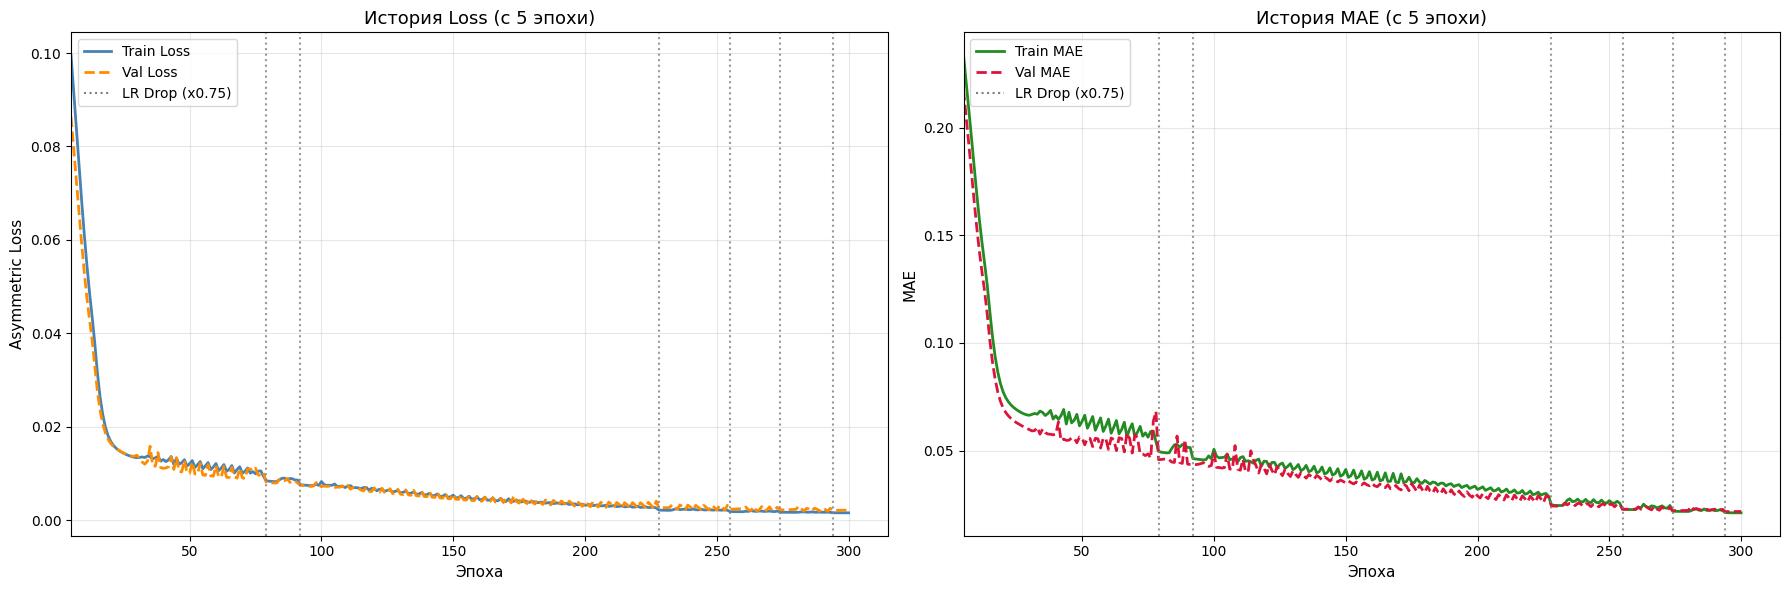

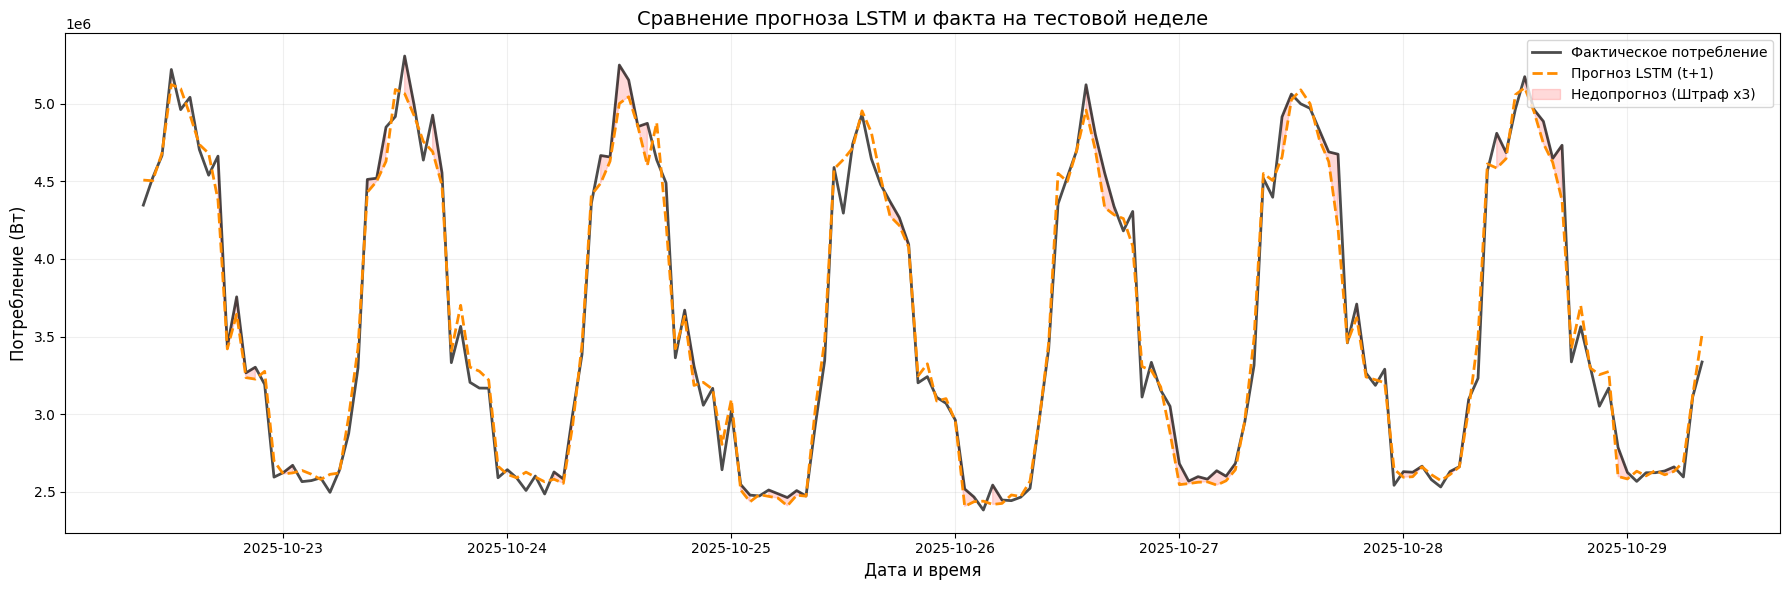

In [23]:
y_pred_log = model_lstm.predict(X_test_scaled)
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

plot_training_history_with_lr(
    history_lstm, 
    start_epoch=5, 
    save_path='data/11_lstm_training_history.png'
)

metrics = evaluate_and_plot_predictions(
    y_test_real=y_test_real, 
    y_pred_real=y_pred_real, 
    dates_test=dates_test, 
    model_name="LSTM",
    save_path='data/12_lstm_predictions.png'
)

# Сохранение весов

In [24]:
model_lstm.save('model_weights/lstm_model.keras')